<a href="https://colab.research.google.com/github/mariannacuevasg-ui/ConnectaTel-project/blob/main/S7_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans

plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users

users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage

usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum().sort_values(ascending=False))
print(users.isna().mean().sort_values(ascending=False))

churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64
churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum().sort_values(ascending=False))
print(usage.isna().mean().sort_values(ascending=False))


duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


In [ ]:

# cantidad de nulos y no-nulos por tipo text/call en usage
# De acuerdo a la lógica general se espera que un text no tenga duración de llamada y que un call no tenga longitud de mensaje. Si esto no se cumple entonces podrían ser valores sentinels de error.

print("Cantidad de nulls en columna duration si es text:", usage[usage['type']=='text']['duration'].isna().sum())
print("Cantidad de no-nulls en columna duration si es text:", usage[usage['type']=='text']['duration'].notna().sum())

print("Cantidad de nulls en columna duration si es call:", usage[usage['type']=='call']['duration'].isna().sum())
print("Cantidad de nulls en columna lenght si es text:", usage[usage['type']=='text']['length'].isna().sum())

print("Cantidad de nulls en columna lenght si es call:", usage[usage['type']=='call']['length'].isna().sum())
print("Cantidad de no-nulls en columna lenght si es call:", usage[usage['type']=='call']['length'].notna().sum())


Cantidad de nulls en columna duration si es text: 22076
Cantidad de no-nulls en columna duration si es text: 16
Cantidad de nulls en columna duration si es call: 0
Cantidad de nulls en columna lenght si es text: 0
Cantidad de nulls en columna lenght si es call: 17896
Cantidad de no-nulls en columna lenght si es call: 12


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

- En el dataset `users`:
  - La columna `churn_date` presenta 88.4% de nulos. Esta columna muestra la fecha en que un usuario canceló el servicio (churn), por lo que es de esperarse que esta columna esté vacia para la mayoría de usuarios. Dado que estamos analizando el comportamiento del usuario, la recomendación es mantener estos valores para poder analizar la tasa de abandono (churn) más adelante.
  - La columna  `city` presenta 11.7% de nulos. La ciudad es un dato que es de utilidad si requerimos realizar una segmentación de usuarios por región. La recomendación es investigar para imputar estos valores nulos con el valor "unknown".
- En el dataset `usage`:
  - La columna `duration` presenta 55.2% de nulos. Se espera que los registros de tipo `text` tengan valores nulos. Sin embargo, se observa que hay 16 registros de tipo `text`con un valor no nulo en la columna `duration`.
  - La columna `lenght` presenta 44.7% de nulos. Se espera que los registros de tipo `call` tengan valores nulos. Sin embargo, se observa que hay 12 registros de tipo `call`con un valor no nulo en la columna `lenght`.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?


 | Columna | Faltantes | Proporción |
  | --- | --- | --- |
  | `churn_date` | 3534 | 0.88350 |
  | `city` | 469 | 0.11725 |
  | `duration` | 22076 | 0.55190 |
  | `lenght` | 17896 | 0.44740 |
- Indica qué harías: ¿imputar, eliminar, ignorar?
   - Para la columna `churn_date`: Ignorar ya que son NaN esperados.
   - Para las columnas `duration` y `lenght`: Ignorar ya que son NaN esperados, sin embargo valdría la pena investigar las 16 filas de tipo text que tienen duration y las 12 filas de tipo call que tienen lenght ya que podrían ser errores del registro del sistema.
   - Para la columna de `city`: Imputar por *unknown*.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users

columnas_numericas = users.select_dtypes(include='number')
print(columnas_numericas.describe())


            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


In [ ]:
# explorar si existen valores duplicados en columna user_id
print("Usuarios duplicados:", users['user_id'].duplicated().sum())

Usuarios duplicados: 0


In [ ]:
# explorar valores sentinels en columna age
print("Sentinels:", users['age'].isin([-999]).sum())

Sentinels: 55


- La columna `user_id`: Se observa que tenemos 4000 usuarios unicos (no duplicados) en la tabla.
- La columna `age`: Se observa que el mínimo es -999, que es un valor improbable (sentinel). Este valor se repite 55 veces en el dataset.

In [ ]:
# explorar columnas numéricas de usage
columnas_numericas = usage.select_dtypes(include='number')
print(columnas_numericas.describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


In [ ]:
# explorar si existen valores duplicados en columnas de id, user_id
print("Registros duplicados:", usage['id'].duplicated().sum())
print("Usuarios duplicados:", usage['user_id'].duplicated().sum())

Registros duplicados: 0
Usuarios duplicados: 36001


- Las columnas `id` y `user_id`: Se observa que hay *40000* registros de llamadas y mensajes con identificador unico (columna `id`). De los cuales, *36001* registros corresponden a usuarios con el mismo user_id.
- Las columnas `duration`y `length`: Se observa poca variabilidad en la columna `duration` (mean = 5.20 vs std = 6.84) y en la columna `length`(mean = 52.12 vs std = 56.61). Sin embargo, los valores min y max están distantes y puede haber presencia de outliers o valores inválidos.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [ ]:
# explorar categorías de city y plan
print(users['city'].value_counts())
print(users['plan'].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` presenta 7 categorías: *Bogotá, CDMX, Medellín, GDL, Cali, MTY, ?*. Siendo *Bogotá* la ciudad con mayor frecuencia (808) en el Dataset. Adicional, se tiene la categoría "?" con 96 registros.
- La columna `plan` presenta 2 categorías: *Basico, Premium*. Siendo *Basico* el plan con mayor frecuencia (2595)

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [ ]:
# explorar categorías de columna type
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` presenta 2 categorías: *text* y *call*. Siendo *text* la categoría con mayor frecuencia (22092) en el Dataset.



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  En la columna `city` con la categoria "?" (96 registros) y en la columna `age` con el valor "-999" (55 registros)
- ¿Qué acción tomarías?
  - Para el caso del valor '?' en la columna `city`, mi recomendación sería imputar estos valores reemplazandolos por un "unknown".
  - Para el caso del valor '-999' en la columna `age`, mi recomendación sería convertir primero a NaN antes de imputar con la media/mediana.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Crear una copia de users dataset
users_clean = users.copy()

In [ ]:
# Convertir a fecha la columna `reg_date` de users

users_clean['reg_date'] = pd.to_datetime(users_clean['reg_date'], errors='coerce')
print(users_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB
None


In [ ]:
# Convertir a fecha la columna `churn_date` de users
# ANTES de convertir, inspecciona el formato real de los valores no nulos
print(users_clean['churn_date'].dropna().head(10))

# Paso 1: reemplazar la coma decimal por punto usando la columna original
churn_date_str = users['churn_date'].astype(str).str.replace(',', '.', regex=False)

# Paso 2: convertir a número (con errors='coerce' para no romper si algo no matchea)
churn_date_num = pd.to_numeric(churn_date_str, errors='coerce')

# Paso 3: convertir a datetime interpretando como nanosegundos
users_clean['churn_date'] = pd.to_datetime(
    churn_date_num.astype('Int64'),
    unit='ns',
    errors='coerce'
)

# Verificar después de convertir
print(users_clean.info())

32   2024-06-13 23:06:40
38   2024-09-12 00:13:20
42   2024-07-22 23:13:20
44   2024-11-10 00:53:20
47   2024-10-08 23:26:40
54   2024-08-13 00:46:40
56   2024-07-25 01:13:20
69   2024-08-02 23:06:40
73   2024-10-05 23:13:20
76   2024-12-13 00:33:20
Name: churn_date, dtype: datetime64[ns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 250.1+ KB
None


In [ ]:
# Crear una copia de usage dataset
usage_clean = usage.copy()

In [ ]:
# Convertir a fecha la columna `date` de usage
usage_clean['date'] = pd.to_datetime(usage_clean['date'], errors='coerce')
print(usage_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB
None


In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users_clean['reg_date'].dt.year.value_counts())
print()
print(users_clean['reg_date'].dt.year.value_counts(normalize=True))

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

2024    0.3325
2023    0.3290
2022    0.3285
2026    0.0100
Name: reg_date, dtype: float64


En `reg_date`, observamos que hay usuarios registrados en *2022, 2023 y 2024*. Sin embargo, se observan *40 registros correspondientes al año 2026*. Lo cual es una fecha fuera de rango que podría ser un error de captura.

In [ ]:
# Revisar los años presentes en `date` de usage
usage_clean['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, observamos que todos los registros de uso con fecha asignada, corresponden al año 2024. No se tienen registros de años previos.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Se observa que en el dataset `users` hay usuarios registrados en años anteriores a 2024: 2022 y 2023, así como en 2026 (año sin transcurrir).
  Sin embargo, en el dataset `usage` solo se tienen registros correspondientes al año 2024.
- ¿Qué harías con ellas?
  `reg_date` 2022/2023 es información válida y útil (por ejemplo, para calcular antigüedad del usuario o cohortes de registro) — no hay que tocarla ni excluir esos usuarios. Lo único que sí amerita tratamiento es: El sentinel 2026 (40 filas, 1%) — aquí el porcentaje es bajo, se podría considerar su eliminación.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
# Paso 1: convertir el sentinel -999 a NaN (ANTES de calcular cualquier estadístico)
users_clean['age'] = users_clean['age'].replace(-999, np.nan)

# Paso 2: calcular la mediana — ya no incluye el sentinel en el cálculo
age_mediana = users_clean['age'].median()

# Paso 3: imputar los NaN (que antes eran -999) con la mediana
users_clean['age'] = users_clean['age'].fillna(age_mediana)

# Verificar cambios
users_clean['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users_clean['city'] = users_clean['city'].replace('?', pd.NA)

# Verificar cambios
print("Número de NaN after: ", users_clean['city'].isna().sum())
print()
print(users_clean['city'].value_counts())

Número de NaN after:  565

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users_clean.loc[users_clean['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print(users_clean.info())
print()
print(users_clean['reg_date'].dt.year.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   float64       
 4   city        3435 non-null   object        
 5   reg_date    3960 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(4)
memory usage: 250.1+ KB
None

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage_clean['duration'].isna().groupby(usage_clean['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Marcar filas con duration como NaN cuando el type = text
usage_clean.loc[(usage_clean['type']=='text') & (usage_clean['duration'].notna()), 'duration'] = np.nan
usage_clean['duration'].isna().groupby(usage_clean['type']).mean()

type
call    False
text     True
Name: duration, dtype: bool

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage_clean['length'].isna().groupby(usage_clean['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

In [ ]:
# Marcar filas con length como NaN cuando el type = call
usage_clean.loc[(usage_clean['type']=='call') & (usage_clean['length'].notna()), 'length'] = np.nan
usage_clean['length'].isna().groupby(usage_clean['type']).mean()

type
call     True
text    False
Name: length, dtype: bool

- Se determina que los nulos en las columnas `duration`y `length` son MAR(Missing At Random), es decir que el faltante no es al azar. Dependen de la variable `type`. Por lo tanto no es necesario imputar.
- NOTA: Se marcaron como "NaN" las filas con valores en `duration`y `length` que tenían algun valor que no correspondía al tipo de uso (text or call) dado que el % era bajo (~ 1%)

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares

usage_clean["is_text"] = (usage_clean["type"] == "text").astype(int) #conocer el total de mensajes
usage_clean["is_call"] = (usage_clean["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage_clean.groupby("user_id")[["is_text", "is_call", "duration"]]\
.agg("sum")\
.reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users_clean, usage_agg, on=['user_id'], how='left')
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = user_profile.select_dtypes(include='number')
print(columnas_numericas.describe())

            user_id          age  cant_mensajes  cant_llamadas  \
count   4000.000000  4000.000000    3999.000000    3999.000000   
mean   11999.500000    48.136000       5.524381       4.478120   
std     1154.844867    17.689919       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.750000    33.000000       4.000000       3.000000   
50%    11999.500000    48.000000       5.000000       4.000000   
75%    12999.250000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              22.836934  
std               16.590213  
min                0.000000  
25%               11.095000  
50%               19.740000  
75%               31.185000  
max              155.690000  


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

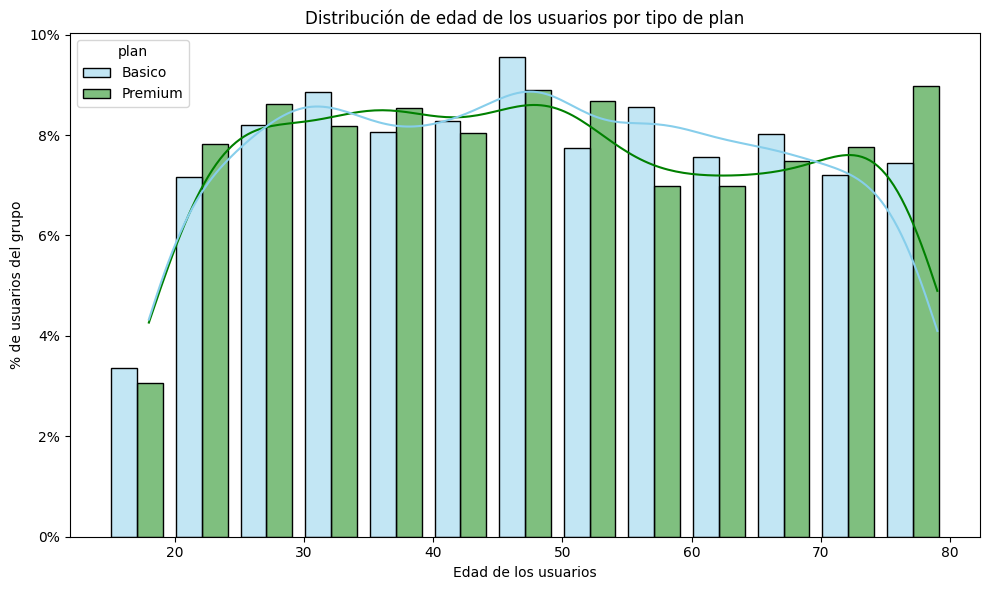

In [ ]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=range(15, 85, 5),
    kde=True,
    multiple='dodge',
    palette=['skyblue', 'green'],
    stat='probability',
    common_norm=False,
    shrink=0.8
)
plt.xlabel('Edad de los usuarios')
plt.ylabel('% de usuarios del grupo')
plt.title('Distribución de edad de los usuarios por tipo de plan')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

💡Insights:

**1. El perfil de edad es prácticamente idéntico entre planes:**
- Las curvas de Básico y Premium se superponen en la mayor parte del rango (20-70 años). Esto indica que la edad no es una variable que distinga a quién elige Premium vs. Básico.
  
**2. Distribución bastante uniforme:**
- La densidad se mantiene relativamente plana entre ~25 y ~75 añols (rondando 7-9% por bin de 5 años en ambos planes). Esto sugiere que la base de usuarios no está concentrada en un segmento etario específico.
- No hay un cliente típico por edad. El producto atrae de forma pareja a distintas generaciones.
  
**3. Los extremos muestran la única divergencia notable:**
- 18-20 años: representa la proporción más baja en ambos grupos(~3%), coherente con un producto que probablemente no se dirige a población muy joven (menores de edad, estudiantes sin ingreso propio, etc.).
- 75-79 años: aquí Premium muestra una proporción notablemente más alta que Básico (~9% vs ~7.5% aprox). Valdría la pena investigar si *¿los usuarios mayores que sí adoptan el servicio tienden a preferir Premium (quizás por más soporte, minutos de llamada, etc.)?*

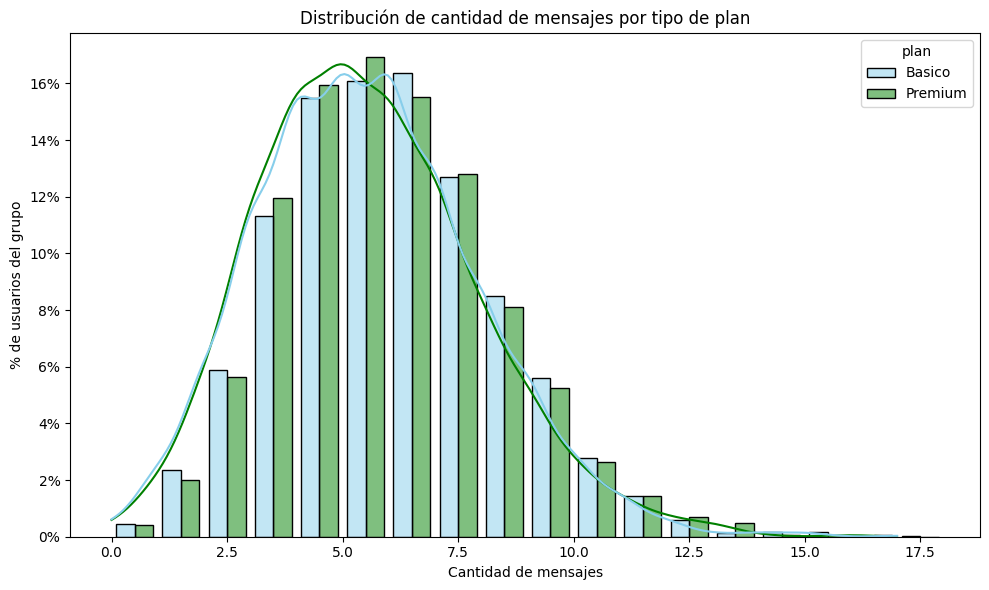

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=range(0, 19, 1),
    kde=True,
    multiple='dodge',
    palette=['skyblue', 'green'],
    stat='probability',
    common_norm=False,
    shrink=0.8
)
plt.xlabel('Cantidad de mensajes')
plt.ylabel('% de usuarios del grupo')
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

💡Insights:

**1. Distribución con forma similar en ambos grupos: unimodal y asimétrica a la derecha:**
- El pico está entre 5-7 mensajes, con una cola larga hacia valores altos (hasta 17) y muy pocos usuarios en 0-1 mensajes. Esto describe un patrón de uso "típico" compartido por toda la base, independientemente del plan.
  
**2. Implicación de negocio: mensajería no es un diferenciador de valor de Premium:**
- Si Premium se vende con la promesa de "más funcionalidad" o "mejor experiencia", el volumen de mensajes no es donde se materializa esa diferencia — los usuarios Premium no mandan más ni menos mensajes que los Básico.

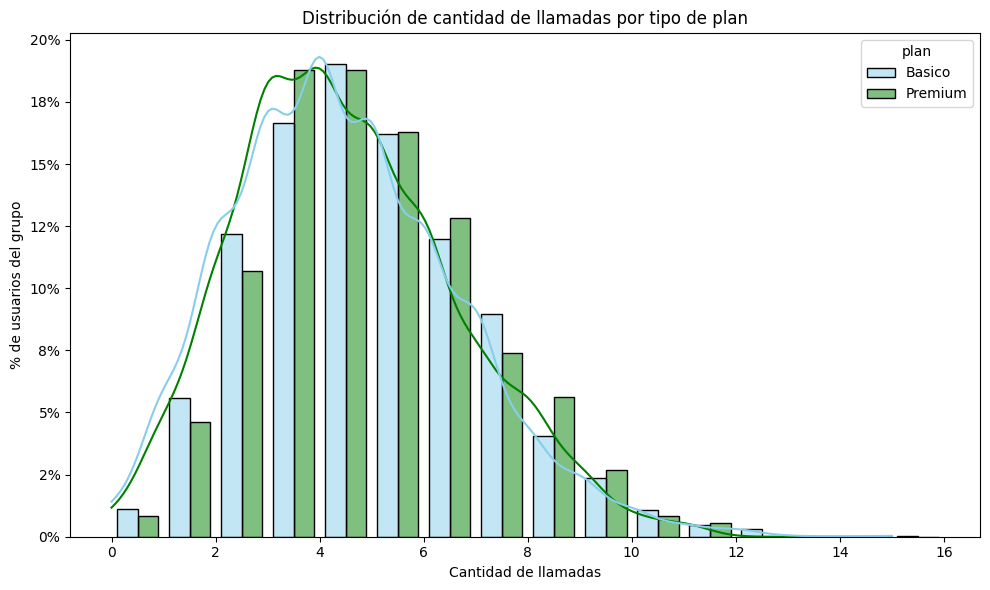

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=range(0, 17, 1),
    kde=True,
    multiple='dodge',
    palette=['skyblue', 'green'],
    stat='probability',
    common_norm=False,
    shrink=0.8
)
plt.xlabel('Cantidad de llamadas')
plt.ylabel('% de usuarios del grupo')
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

💡Insights:

**1. Misma forma de distribución en ambos planes:**
- Unimodal y asimétrica a la derecha, pico entre 3-5 llamadas, cola larga hasta 15.
- El patrón visual es consistente con lo que vimos en `cant_mensajes` — ambos planes comparten un comportamiento de uso muy similar en volumen.

**2. Patrón que se repite:**
- Ni mensajes ni llamadas diferencian Básico de Premium.
- El plan que un usuario contrata no está asociado a cuánto usa el servicio en volumen de interacciones. Esto tiene sentido de negocio si Premium se diferencia por otro tipo de valor (ej. calidad de llamada, minutos incluidos, soporte prioritario) más que por frecuencia de uso.

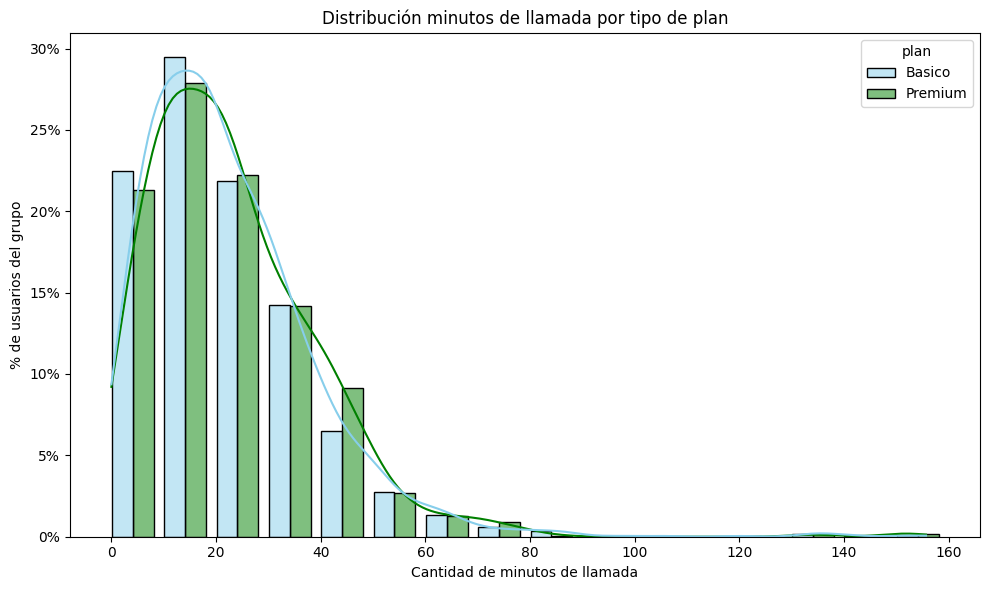

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    bins=range(0, 165, 10),
    kde=True,
    multiple='dodge',
    palette=['skyblue', 'green'],
    stat='probability',
    common_norm=False,
    shrink=0.8
)
plt.xlabel('Cantidad de minutos de llamada')
plt.ylabel('% de usuarios del grupo')
plt.title('Distribución minutos de llamada por tipo de plan')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

💡Insights:

**1. Distribución con forma consistente: asimétrica a la derecha**

- Ambos planes muestran el mismo patrón: la mayoría de los usuarios se concentra entre 0 y 30 minutos, con una cola larga y decreciente hacia valores altos (hasta ~155 min.).
- Esta forma es típica de variables de consumo telefónico, donde pocos usuarios de alto uso elevan el promedio muy por encima de la mediana (~20 min vs. media ~23 min).

**2. Implicación de negocio:**

Con tres variables de uso (mensajes, llamadas, minutos) mostrando el mismo resultado —sin diferencia significativa entre planes—, se refuerza una conclusión más amplia: el volumen de actividad del usuario no está asociado al plan que contrata. Esto sugiere que la elección de Premium probablemente responde a otros factores como calidad del servicio, soporte, cobertura, o motivaciones no relacionadas con el uso, como el precio o percepción de la marca.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

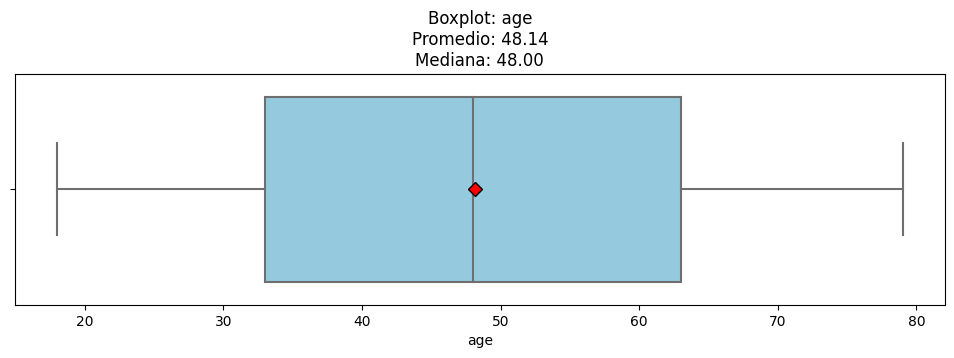

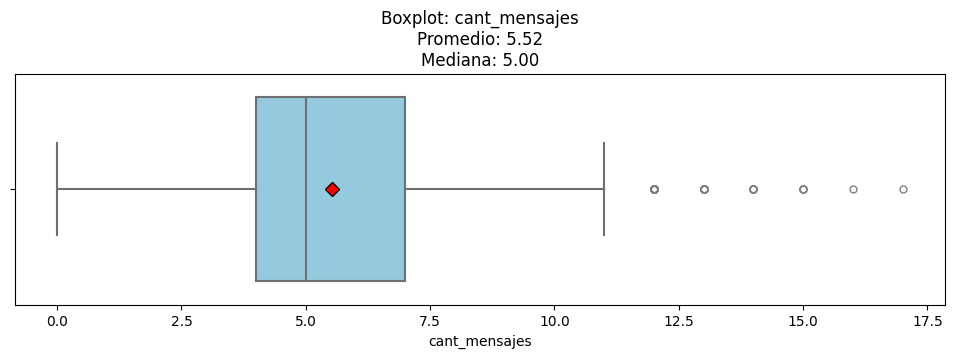

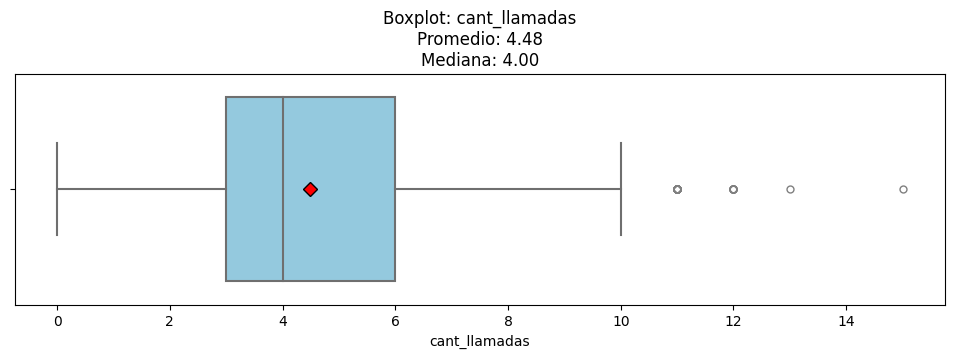

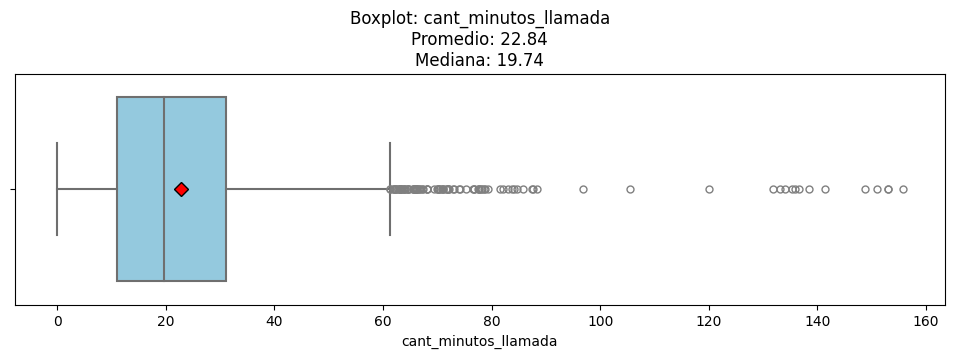

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(12,3))
    sns.boxplot(
        data=user_profile,
        x=col,
        showmeans=True,
        color='skyblue',
        meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markeredgecolor': 'black', 'markersize': 7},
        flierprops={'marker': 'o', 'markerfacecolor': 'none', 'markeredgecolor': 'gray', 'markersize': 5}
)
    mean_value = user_profile[col].mean()
    median_value = user_profile[col].median()
    plt.title(f'Boxplot: {col}\nPromedio: {mean_value:.2f}\nMediana: {median_value:.2f}')
    plt.show()


💡Insights:

**1. Age:** Es la única variable completamente limpia de outliers.

**2. cant_mensajes:** El grueso de los datos está entre 0 y 12. Por encima de eso aparecen valores de 13 a 17 mensajes, decrecientes en frecuencia — una cola larga pero continua, sin saltos abruptos ni un valor que se repita de forma sospechosa en el extremo. Nada que grite "error de carga", más bien usuarios con mayor actividad.

**3. cant_llamadas:** Mismo patrón: cola que va de 10 hasta 15 (máximo), de forma gradual. El valor 15 aparece una sola vez, 13 una vez, luego varios 12 — decreciendo suavemente.

**4. cant_minutos_llamada:** Hay un grupo de valores muy altos, entre 135 y 155.69 minutos, que están notablemente separados del resto de la distribución.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
resumen = []

for col in columnas_limites:
    #calcular Q1, Q3 e IQR
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1

    #Calcular límite inferior y superior
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtrar outliers
    outliers_abajo = user_profile[user_profile[col] < limite_inferior]
    outliers_arriba = user_profile[user_profile[col] > limite_superior]
    total_outliers = len(outliers_abajo) + len(outliers_arriba)

    # Guardar resultados en tabla resumen
    resumen.append({
        'Columna': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite inferior': limite_inferior,
        'Limite superior': limite_superior,
        'Outliers abajo': len(outliers_abajo),
        'Outliers arriba': len(outliers_arriba),
        'Total outliers': total_outliers,
        '% outliers': round(total_outliers / user_profile[col].notna().sum() * 100, 2)
    })

#Mostrar tabla resumen
tabla_resumen = pd.DataFrame(resumen)
print(tabla_resumen)


                Columna      Q1      Q3    IQR  Limite inferior  \
0         cant_mensajes   4.000   7.000   3.00            -0.50   
1         cant_llamadas   3.000   6.000   3.00            -1.50   
2  cant_minutos_llamada  11.095  31.185  20.09           -19.04   

   Limite superior  Outliers abajo  Outliers arriba  Total outliers  \
0            11.50               0               46              46   
1            10.50               0               30              30   
2            61.32               0               96              96   

   % outliers  
0        1.15  
1        0.75  
2        2.40  


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights:
- Los outliers de `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada` son valores continuos, variados y decrecientes gradualmente en la cola (17, 16, 15... mensajes; 155.69, 153.06, 150.92... minutos). No hay ningún valor repetido de forma sospechosa.
- Todos los outliers están en el extremo superior: Todos representan usuarios de alto uso, no valores corruptos o faltantes disfrazados.
- Eliminarlos sesgaría el análisis, no lo limpiaría: Si el objetivo del proyecto es "entender comportamiento de clientes", quitar a los usuarios más activos (2.4% en minutos, ~1% en mensajes/llamadas) no es limpiar ruido — es borrar un segmento real de la base de clientes, precisamente el que probablemente más le interesa al negocio: los *heavy users*.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


def classify_use (user_profile):
    mensajes = user_profile['cant_mensajes']
    llamadas = user_profile['cant_llamadas']

    # 1. Manejo de valores nulos/faltantes
    if pd.isna(mensajes) or pd.isna(llamadas):
        return "Error en Datos"

    # 2. Segmentación
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# aplicar función
user_profile['grupo_uso'] = user_profile.apply(classify_use, axis=1)



In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def classify_age (user_profile):
    edad = user_profile['age']

    # 1. Manejo de valores nulos/faltantes
    if pd.isna(edad):
        return "Error en Datos"

    # 2. Segmentación
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# aplicar función
user_profile['grupo_edad'] = user_profile.apply(classify_age, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [ ]:
# Cruce de grupo_grupo_uso y plan

pd.crosstab(user_profile['grupo_uso'], user_profile['plan'], normalize='index')*100

plan,Basico,Premium
grupo_uso,,
Alto uso,66.546763,33.453237
Bajo uso,65.809769,34.190231
Error en Datos,100.000000,0.000000
Uso medio,64.458036,35.541964


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

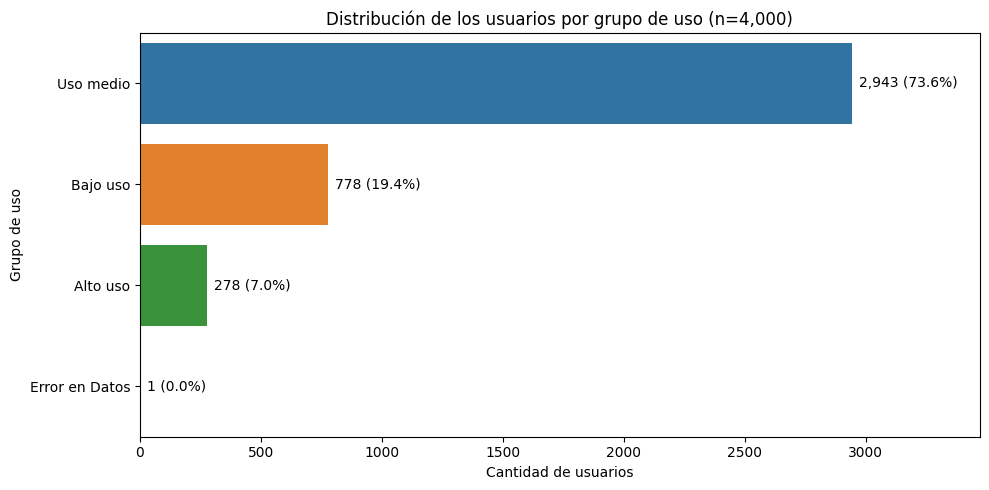

In [ ]:
# Visualización de los segmentos por uso

plt.figure(figsize=(10, 5))

orden = user_profile['grupo_uso'].value_counts().index

ax = sns.countplot(
    data=user_profile,
    y='grupo_uso',
    order=orden
)

total = len(user_profile)
for p in ax.patches:
    width = p.get_width()
    pct = width / total * 100
    ax.annotate(
        f'{int(width):,} ({pct:.1f}%)',
        (width, p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=10, xytext=(5, 0),
        textcoords='offset points'
    )

plt.title(f'Distribución de los usuarios por grupo de uso (n={total:,})')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Grupo de uso')
plt.xlim(0, user_profile['grupo_uso'].value_counts().max() * 1.18)
plt.tight_layout()
plt.show()


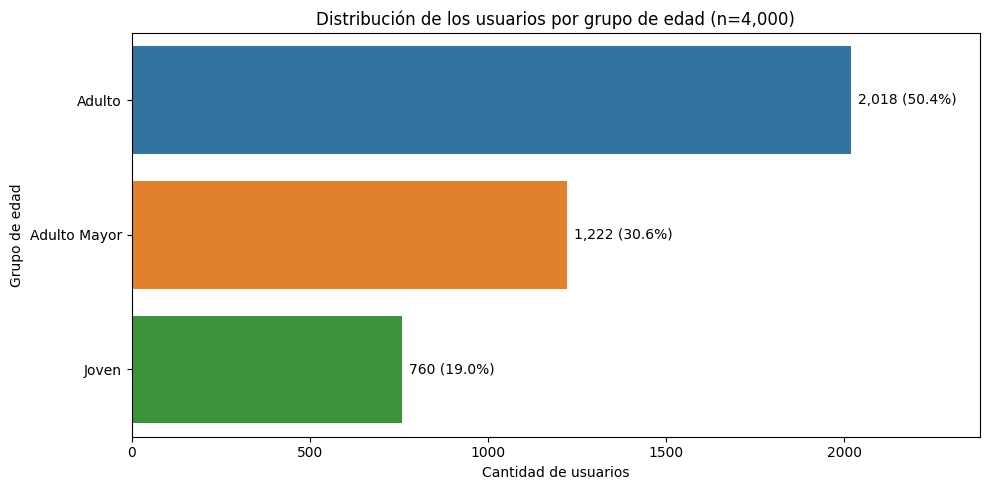

In [ ]:
# Visualización de los segmentos por edad

plt.figure(figsize=(10, 5))

orden = user_profile['grupo_edad'].value_counts().index

ax = sns.countplot(
    data=user_profile,
    y='grupo_edad',
    order=orden
)

total = len(user_profile)
for p in ax.patches:
    width = p.get_width()
    pct = width / total * 100
    ax.annotate(
        f'{int(width):,} ({pct:.1f}%)',
        (width, p.get_y() + p.get_height() / 2),
        ha='left', va='center', fontsize=10, xytext=(5, 0),
        textcoords='offset points'
    )

plt.title(f'Distribución de los usuarios por grupo de edad (n={total:,})')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Grupo de edad')
plt.xlim(0, user_profile['grupo_edad'].value_counts().max() * 1.18)
plt.tight_layout()
plt.show()


In [ ]:
# exportar tabla
user_profile.to_csv('user_profile.csv', index=False)



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

**Resumen ejecutivo**

El presente análisis evalúo la calidad de los datos de clientes de ConnectaTel —partiendo de tres datasets originales (users, plans y usage) unidos en user_profile.csv tras su limpieza—, construyó segmentos de negocio por edad y nivel de uso, y contrastó estadísticamente el comportamiento de los planes Básico y Premium. El hallazgo central es que ni la edad ni el volumen de uso (mensajes, llamadas o minutos) diferencian de forma significativa a quién elige cada plan. Esto indica que la oferta actual de planes no está diferenciada por comportamiento de uso, y que existe una oportunidad clara de crear una propuesta dirigida al 7% de clientes de "Alto uso", que hoy en su mayoría (66.5%) permanecen en el plan Básico.


⚠️ **Problemas detectados en los datos**

El proyecto partió de tres datasets crudos: `users, plans y usage`. Tras un proceso de limpieza, users y usage se unieron para construir `user_profile.csv` (4,000 filas), el dataset actualmente en uso. A continuación se documentan los problemas detectados en los datasets originales y cómo se resolvieron, seguidos del estado de calidad de datos que persiste en user_profile.csv después de ese proceso.

**Problemas detectados en los datasets originals (users, usage)**
| Dataset original | Columnas | Problema identificado | Tratamiendo aplicado |
| --- | --- | --- | --- |
| users | age | Valor sentinel -999 usado como marcador de dato faltante | Reemplazar -999 por la mediana de age |
| users | city | Valor sentinel "?" usado como marcador de dato faltante | Reemplazar ? por NA en city |
| users | reg_date | Fecha futura repetida (2026) - Sentinel de registro inválido | Marcar fechas futuras como NA para reg_date |
| users / usage | reg_date, churn_date | Formato incorrecto para fechas | Convertir a fecha la columna `reg_date` y `churn_date` de users y usage |
| usage | duration/lenght | Códigos de error inferidos (120.0 y 1490.0) por repetición exacta y ruptura de la distribución | Pendiente de confirmar con el dueño de los datos |

**Estado residual en user_profile.csv, tras la limpieza y unión**

La limpieza previa fue efectiva para los sentinels de `age` y `city` detectados en el dataset original de `users`: ninguno de los dos aparece ya en `user_profile.csv.` Sin embargo, persisten problemas de calidad, algunos heredados del proceso de unión:

| Columnas | Problema identificado | Filas afectadas | % del total | Tratamiendo aplicado / recomendado |
| --- | --- | --- | --- | --- |
| city | Valores faltantes (nulos) | 565 | 14.12% | Imputar con categoría explícita "Desconocido" |
| reg_date | Valores faltantes (nulos) | 40 | 1.00% | Excluir solo estas filas de análisis basados en fecha de registro |
| churn_date | Valores faltantes (nulos) | 3,534 | 88.35% |  Nulos esperados y correctos: representan usuarios que no han cancelado |
| cant_mensajes / cant_llamadas / cant_minutos_llamada | 1 fila con las tres métricas de uso nulas simultáneamente | 1 | 0.03% | Clasificada explícitamente como "Error en Datos" en la segmentación por uso, en vez de imputarse |

**Outliers**
Usando el método de rango intercuartílico (IQR) sobre las tres variables de uso, se identificaron los siguientes outliers, todos concentrados en el extremo superior (ningún outlier por valores anormalmente bajos):
| Variable | Límite superior (IQR) | Outliers | % del total | Máx. observado |
| --- | --- | --- | --- |--- |
| cant_mensajes | 11.5 mensajes | 46 | 1.15% | 17 |
| cant_llamadas | 10.5 llamadas | 30 | 0.75% | 15 |
| cant_minutos_llamadas | 61.3 minutos | 96 | 2.40% | 155.7 |

A diferencia de los sentinels de error detectados en auditorías previas del proyecto (valores repetidos de forma idéntica, como códigos de error), estos outliers son valores continuos y variados — no hay un valor que se repita de forma sospechosa en el extremo. Esto indica que se trata de comportamiento real de "heavy users", no de errores de carga o corrupción de datos.

🔍 **Segmentos de clientes identificados**

Se construyeron dos segmentaciones categóricas:
 - grupo_edad (Joven <30, Adulto 30-59, Adulto Mayor 60+)
 - grupo_uso (Bajo, Medio y Alto Uso, según volumen de llamadas y mensajes)

**Segmentos por Edad**

- Adulto (30-59 años): 2,018 usuarios (50.4%)
- Adulto Mayor (60+ años): 1,222 usuarios (30.6%)
- Joven (<30 años): 760 usuarios (19.0%)


**Segmentos por Nivel de Uso**

- Uso medio: 2,943 usuarios (73.6%)
- Bajo uso: 778 usuarios (19.4%)
- Alto uso: 278 usuarios (7.0%)

➡️ Esto sugiere que el segmento de "Alto uso" (278 clientes, 7.0%) es el más valioso a nivel de comportamiento e ingreso potencial, por la siguientes razones:
- Consumen significativamente más que el resto: en promedio 9.56 mensajes, 5.95 llamadas y 29.72 minutos, frente a 5.78 / 4.78 / 24.32 del segmento de uso medio.
- Representan al cliente más activo y probablemente más dependiente del servicio, con mayor riesgo de fricción si su plan no cubre su consumo real.
- El 66.5% de este segmento está en el plan Básico, lo que sugiere una oportunidad de upsell no capturada actualmente.

En contraste, los segmentos por edad no muestran diferencias de valor entre sí: Jóvenes, Adultos y Adultos Mayores consumen de forma casi idéntica y adoptan Premium en proporciones similares. Esto significa que, para efectos de priorización comercial, el nivel de uso es una variable de segmentación mucho más accionable que la edad.


💡 **Recomendaciones**

**Sobre la oferta de planes**

- Crear un plan o add-on dirigido específicamente al segmento de Alto uso (7%), dado que dos tercios de estos clientes ya consumen por encima del promedio estando en el plan Básico - son candidatos a upsell.
- No usar la edad como criterio de diferenciación de planes: los tres grupos etarios consumen de forma prácticamente idéntica, por lo que un plan "para jóvenes" o para "adultos mayores" no tendría sustento en el comportamiento real de uso.
- Investigar qué variable sí explica la elección de Premium, ya que ni edad ni volumen de uso lo hacen. Revisar factores como precio, cobertura por ciudad, calidad de llamada, soporte al cliente o antigüedad del usuario.

**Sobre la calidad de datos**

- Reducir el 14.12% de valores faltantes en city, ya que impide un análisis geográfico confiable de la demanda y podría estar ocultando diferencias regionales relevantes para pricing o cobertura.
- Mantener (no eliminar) los outliers de uso identificados; en su lugar, incorporarlos como un segmento de seguimiento (ej. Bandera "cliente_alto_valor").


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`